In [3]:
# Basic import 
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

#Modeling
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, AdaBoostRegressor
from sklearn.svm import SVR
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.model_selection import RandomizedSearchCV

from catboost import CatBoostRegressor
from xgboost  import XGBRegressor
import warnings

In [4]:
df = pd.read_csv('data/stud.csv')
df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [8]:
# Preparing X and Y variables

In [5]:
X = df.drop(columns=['math score'],axis=1)

In [6]:
Y = df['math score']

In [12]:
print(X.head())

   gender race/ethnicity parental level of education         lunch  \
0  female        group B           bachelor's degree      standard   
1  female        group C                some college      standard   
2  female        group B             master's degree      standard   
3    male        group A          associate's degree  free/reduced   
4    male        group C                some college      standard   

  test preparation course  reading score  writing score  
0                    none             72             74  
1               completed             90             88  
2                    none             95             93  
3                    none             57             44  
4                    none             78             75  


In [13]:
print(Y.head())

0    72
1    69
2    90
3    47
4    76
Name: math score, dtype: int64


In [8]:
# Create Column Transformer with 3 types of transformers
num_features = X.select_dtypes(exclude="object").columns
cat_features = X.select_dtypes(include="object").columns
print(num_features,cat_features)

Index(['reading score', 'writing score'], dtype='object') Index(['gender', 'race/ethnicity', 'parental level of education', 'lunch',
       'test preparation course'],
      dtype='object')


In [9]:
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer

numerical_transformer = StandardScaler()
oh_transformer = OneHotEncoder()

preprocessor = ColumnTransformer(
    [
        ("OneHotEncoder", oh_transformer,cat_features),
        ("StandardScaler",numerical_transformer,num_features),
    ]
)


In [10]:
x = preprocessor.fit_transform(X)

In [11]:
print(x)

[[ 1.          0.          0.         ...  1.          0.19399858
   0.39149181]
 [ 1.          0.          0.         ...  0.          1.42747598
   1.31326868]
 [ 1.          0.          0.         ...  1.          1.77010859
   1.64247471]
 ...
 [ 1.          0.          0.         ...  0.          0.12547206
  -0.20107904]
 [ 1.          0.          0.         ...  0.          0.60515772
   0.58901542]
 [ 1.          0.          0.         ...  1.          1.15336989
   1.18158627]]


In [12]:
x.shape

(1000, 19)

In [20]:
# Separate the dataset into train and test
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(x,Y,test_size=0.2,random_state = 42)

In [21]:
X_train.shape

(800, 19)

In [22]:
X_test.shape

(200, 19)

In [23]:
y_train.shape

(800,)

In [24]:
y_test.shape

(200,)

In [25]:
print(x.shape, Y.shape)

(1000, 19) (1000,)


In [26]:
# Create and evaluate function to give all metrics after model training 
def evaluate_model(true, predicted):
    mae = mean_absolute_error(true,predicted)
    mse = mean_squared_error(true,predicted)
    rmse = np.sqrt(mean_squared_error(true,predicted))
    r2_square = r2_score(true,predicted)
    return mae,rmse,r2_square

In [30]:
models = {
    "Linear Regression": LinearRegression(),
    "Lasso": Lasso(),
    "Ridge": Ridge(),
    "K-Neighbors Regressor":KNeighborsRegressor(),
    "Decision Tree Regressor":DecisionTreeRegressor(),
    "Random Forest Regressor":RandomForestRegressor(),
    "XGBRegressor":XGBRegressor(),
    "CatBoosting Regressor":CatBoostRegressor(),
    "AdaBoost Regressor":AdaBoostRegressor(),
}
model_list = []
r2_list = []

for i in range(len(list(models))):
    model = list(models.values())[i]
    model.fit(X_train, y_train) # Train Model

    # Make Prediction:
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    # Evaluate Train and Test Dataset
    model_train_mae, model_tain_rmse, model_train_r2 = evaluate_model(y_train,y_train_pred)
    model_test_mae, model_test_rmse, model_test_r2 = evaluate_model(y_test,y_test_pred)

    print(list(models.keys())[i])
    model_list.append(list(models.keys())[i])

    print('Model performance for Training Set')
    print('- Root Mean Square Error: {:.4f}'.format(model_tain_rmse))
    print('- Mean Absolute Error: {:.4f}'.format(model_train_mae))
    print('- R2 Score: {:.4f}'.format(model_train_r2))

    print('Model performance for Test Set')
    print('- Root Mean Square Error: {:.4f}'.format(model_test_rmse))
    print('- Mean Absolute Error: {:.4f}'.format(model_test_mae))
    print('- R2 Score: {:.4f}'.format(model_test_r2))

    r2_list.append(model_test_r2)

    print('='*35)
    print('\n')


Linear Regression
Model performance for Training Set
- Root Mean Square Error: 5.3273
- Mean Absolute Error: 4.2783
- R2 Score: 0.8741
Model performance for Test Set
- Root Mean Square Error: 5.4102
- Mean Absolute Error: 4.2272
- R2 Score: 0.8797


Lasso
Model performance for Training Set
- Root Mean Square Error: 6.5938
- Mean Absolute Error: 5.2063
- R2 Score: 0.8071
Model performance for Test Set
- Root Mean Square Error: 6.5197
- Mean Absolute Error: 5.1579
- R2 Score: 0.8253


Ridge
Model performance for Training Set
- Root Mean Square Error: 5.3233
- Mean Absolute Error: 4.2650
- R2 Score: 0.8743
Model performance for Test Set
- Root Mean Square Error: 5.3904
- Mean Absolute Error: 4.2111
- R2 Score: 0.8806


K-Neighbors Regressor
Model performance for Training Set
- Root Mean Square Error: 5.7122
- Mean Absolute Error: 4.5187
- R2 Score: 0.8553
Model performance for Test Set
- Root Mean Square Error: 7.2516
- Mean Absolute Error: 5.6160
- R2 Score: 0.7839


Decision Tree Regres

In [32]:
pd.DataFrame(list(zip(model_list,r2_list)),columns=['Model Name', 'R2_Score']).sort_values(by=['R2_Score'],ascending=False)

,Model Name,R2_Score
2,Ridge,0.880593
0,Linear Regression,0.879715
5,Random Forest Regressor,0.851911
7,CatBoosting Regressor,0.851632
8,AdaBoost Regressor,0.846738
6,XGBRegressor,0.827797
1,Lasso,0.825320
3,K-Neighbors Regressor,0.783898
4,Decision Tree Regressor,0.749649


In [33]:
lin_model = LinearRegression(fit_intercept=True)
lin_model = lin_model.fit(X_train,y_train)
y_pred = lin_model.predict(X_test)
score = r2_score(y_test,y_pred) * 100
print('Accuracy of the model is %.2f' %score)

Accuracy of the model is 87.97


Text(0, 0.5, 'Predicted')

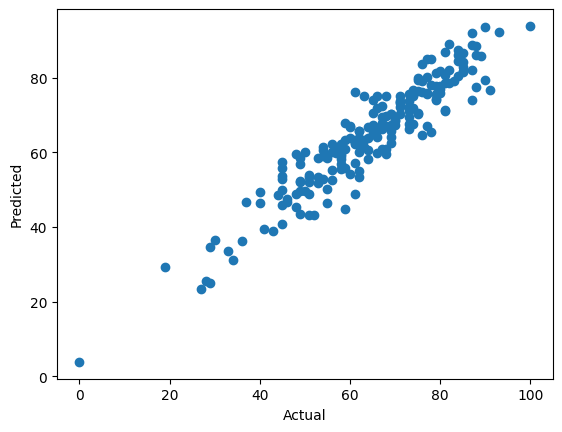

In [34]:
plt.scatter(y_test,y_pred)
plt.xlabel('Actual')
plt.ylabel('Predicted')

<Axes: xlabel='math score'>

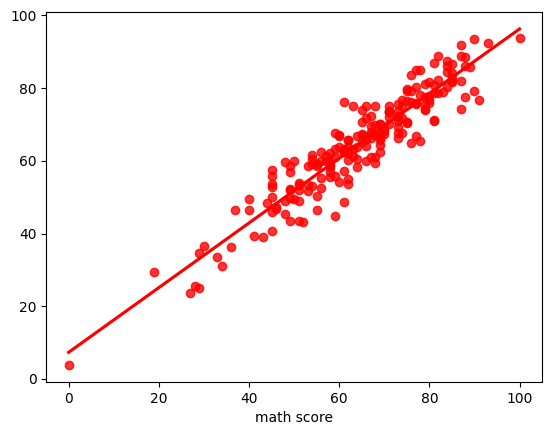

In [35]:
sns.regplot(x=y_test,y=y_pred,ci=None,color='red')

In [36]:
pred_df = pd.DataFrame({'Actual Values': y_test,'Predicted Values': y_pred,'Difference':y_test - y_pred})

In [37]:
print(pred_df)

     Actual Values  Predicted Values  Difference
521             91         76.718750   14.281250
737             53         58.593750   -5.593750
740             80         76.843750    3.156250
660             74         76.750000   -2.750000
411             84         87.500000   -3.500000
..             ...               ...         ...
408             52         43.140625    8.859375
332             62         62.125000   -0.125000
208             74         67.578125    6.421875
613             65         67.343750   -2.343750
78              61         62.328125   -1.328125

[200 rows x 3 columns]
